# Projeto reconhecimento de dígitos manuscritos

Etapas:

- Carregar dados
- Definir modelo Keras
- Compilar modelo Keras
- Ajustar (fit) modelo Keras
- Avaliar (evalute) modelo Keras
- Faça previsões (predict)

## Carregar dados

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import tensorflow as tf
from tensorflow import keras

mnist = keras.datasets.mnist

In [3]:
mnist

<module 'keras.datasets.mnist' from 'C:\\Users\\toscac0303\\.conda\\envs\\MachineLearning\\Lib\\site-packages\\keras\\datasets\\mnist\\__init__.py'>

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [6]:
type(x_train[0])

numpy.ndarray

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
x_train[0][0].shape

(28,)

In [9]:
y_train.shape

(60000,)

In [10]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [11]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [12]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [13]:
contagem = tuple(zip(*np.unique(y_train, return_counts=True)))
contagem

((np.uint8(0), np.int64(5923)),
 (np.uint8(1), np.int64(6742)),
 (np.uint8(2), np.int64(5958)),
 (np.uint8(3), np.int64(6131)),
 (np.uint8(4), np.int64(5842)),
 (np.uint8(5), np.int64(5421)),
 (np.uint8(6), np.int64(5918)),
 (np.uint8(7), np.int64(6265)),
 (np.uint8(8), np.int64(5851)),
 (np.uint8(9), np.int64(5949)))

In [14]:
for par in contagem:
    print(f"{par[0]}: {par[1] / len(y_train) * 100:.2f}%")

0: 9.87%
1: 11.24%
2: 9.93%
3: 10.22%
4: 9.74%
5: 9.04%
6: 9.86%
7: 10.44%
8: 9.75%
9: 9.92%


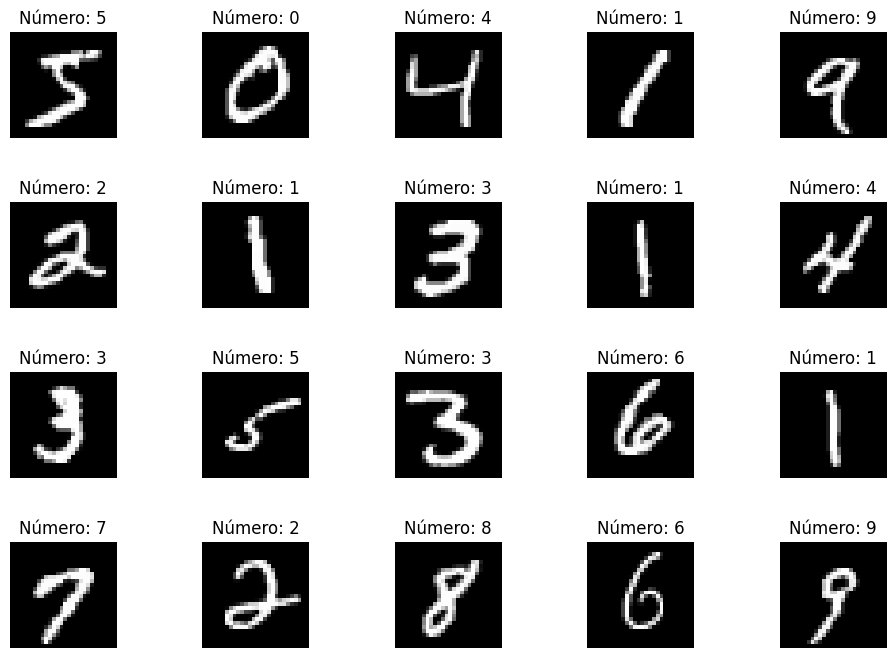

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Número: {y_train[i]}")
    ax.axis("off")

fig.subplots_adjust(hspace=0.6)

plt.show()

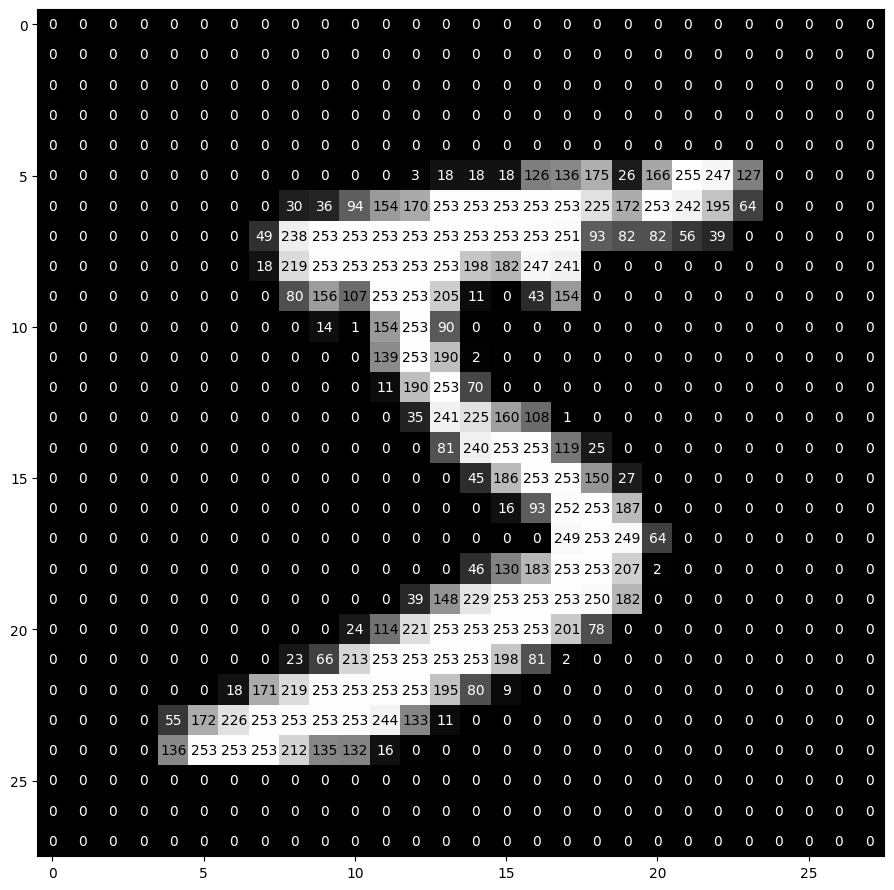

In [16]:
fig, ax = plt.subplots(figsize=(11, 11))

ax.imshow(x_train[0], cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna]
        ax.annotate(
            str(valor),
            xy=(coluna, linha),
            color="black" if valor > 100 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

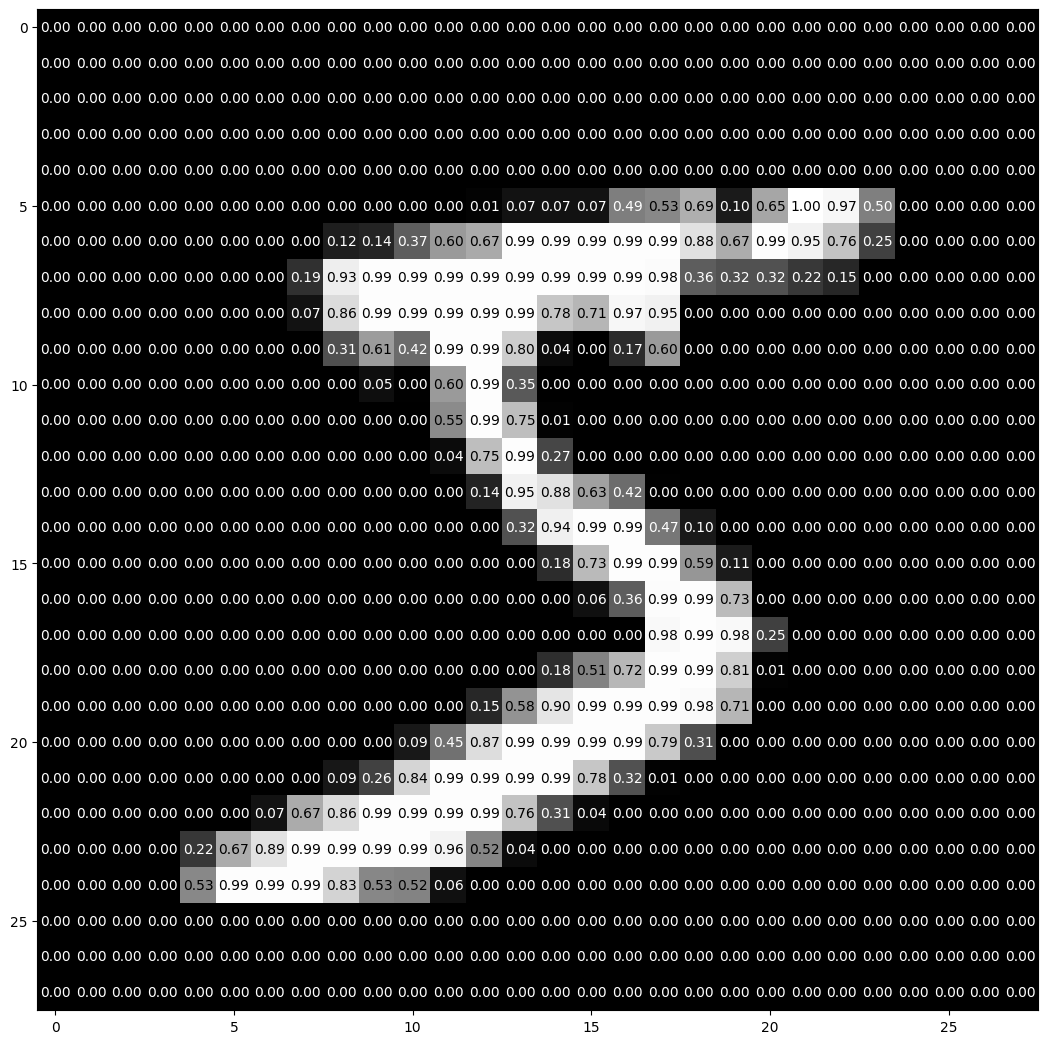

In [17]:
fig, ax = plt.subplots(figsize=(13, 13))

ax.imshow(x_train[0] / 255, cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna] / 255
        ax.annotate(
            f"{valor:.2f}",
            xy=(coluna, linha),
            color="black" if valor > 0.5 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

## Definir função Tuner

`pip install -q -U keras-tuner`

https://www.tensorflow.org/tutorials/keras/keras_tuner

https://keras.io/api/keras_tuner/tuners/

In [18]:
def model_builder(hp):
    model = keras.models.Sequential()
    
    model.add(keras.layers.InputLayer(shape=(28, 28, 1)))
    model.add(keras.layers.Rescaling(scale=1./255))
    
    model.add(keras.layers.RandomRotation(0.1))
    model.add(keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1))
    model.add(keras.layers.RandomZoom(0.1))
    
    model.add(keras.layers.Conv2D(
        hp.Int("conv_1_filters",  min_value=16, max_value=64, step=2, sampling="log"), 
        (3, 3),  
        activation="relu"))
    model.add(keras.layers.MaxPooling2D())
    model.add(keras.layers.Dropout(0.2))
    
    model.add(keras.layers.Conv2D(
        hp.Int("conv_2_filters",  min_value=32, max_value=128, step=2, sampling="log"), 
        (3, 3),  
        activation="relu"))
    model.add(keras.layers.MaxPooling2D())
    model.add(keras.layers.Dropout(0.2))
    
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(10, activation="softmax"))


    optimizer = keras.optimizers.Adam(learning_rate=hp.Choice("learning_rate", values=[1E-2, 1E-3, 1E-4]))
    loss = keras.losses.SparseCategoricalCrossentropy()
    metric = keras.metrics.SparseCategoricalAccuracy()
    
    model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

    return model

In [19]:
import keras_tuner as kt

tuner = kt.Hyperband(
    model_builder,
    objective="val_loss",
    max_epochs=10,
    factor=3,
    directory="tuner",
    project_name="mnist",
)

Reloading Tuner from tuner\mnist\tuner0.json


## Fit modelo Keras

In [20]:
early_stop = keras.callbacks.EarlyStopping(
    patience=5,
    verbose=1,
    min_delta=1E-4,
)

tuner.search(
    x_train,
    y_train,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
)

Trial 26 Complete [00h 01m 36s]
val_loss: 0.06447818130254745

Best val_loss So Far: 0.05832501873373985
Total elapsed time: 00h 24m 43s


In [21]:
best_hps = tuner.get_best_hyperparameters()[0]

In [22]:
best_hps.values

{'conv_1_filters': 64,
 'conv_2_filters': 64,
 'learning_rate': 0.01,
 'tuner/epochs': 10,
 'tuner/initial_epoch': 4,
 'tuner/bracket': 1,
 'tuner/round': 1,
 'tuner/trial_id': '0019'}

In [23]:
model = tuner.hypermodel.build(best_hps)

history = model.fit(
    x_train,
    y_train,
    epochs = 50,
    batch_size = 512,
    validation_split = 0.2,
    callbacks = [early_stop]
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 0.7166 - sparse_categorical_accuracy: 0.7711 - val_loss: 0.1043 - val_sparse_categorical_accuracy: 0.9703
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - loss: 0.2831 - sparse_categorical_accuracy: 0.9123 - val_loss: 0.0763 - val_sparse_categorical_accuracy: 0.9772
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - loss: 0.2197 - sparse_categorical_accuracy: 0.9303 - val_loss: 0.0718 - val_sparse_categorical_accuracy: 0.9786
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - loss: 0.1977 - sparse_categorical_accuracy: 0.9374 - val_loss: 0.0847 - val_sparse_categorical_accuracy: 0.9772
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - loss: 0.1776 - sparse_categorical_accuracy: 0.9445 - val_loss: 0.0692 - val_sparse_categorical_accuracy: 0.9799
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - loss: 0.1636 - sparse_categorical_accuracy: 0.9490 - val_loss: 0.0693 - val_sparse_categorical_accuracy: 0.980

In [24]:
model.save("model/model_best_hps.keras")

## Evaluate modelo Keras

In [39]:
loaded_model = keras.models.load_model("model/model_best_hps.keras")

In [40]:
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_1 (RandomRotation)   │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation_1                 │ (None, 28, 28, 1)           │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_1 (RandomZoom)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,736 (627.88 KB)

 Trainable params: 53,578 (209.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 107,158 (418.59 KB)

In [41]:
loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0600 - sparse_categorical_accuracy: 0.9843


[0.0599953718483448, 0.9843000173568726]

## Predict modelo Keras

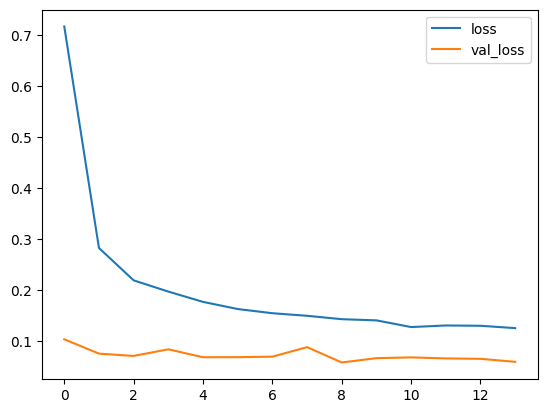

In [28]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

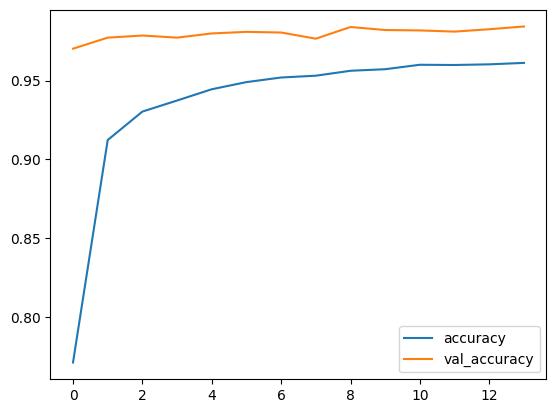

In [29]:
plt.plot(history.history["sparse_categorical_accuracy"], label="accuracy")
plt.plot(history.history["val_sparse_categorical_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

In [30]:
x_test[0].shape

(28, 28)

In [31]:
np.expand_dims(x_test[0], axis=0).shape

(1, 28, 28)

In [32]:
model.predict(np.expand_dims(x_test[0], axis=0))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


array([6.2534433e-08, 3.5870823e-07, 1.0751957e-04, 1.0000483e-08,
       1.7991178e-11, 1.8990082e-11, 1.2004993e-16, 9.9989200e-01,
       8.3803426e-09, 3.0178584e-09], dtype=float32)

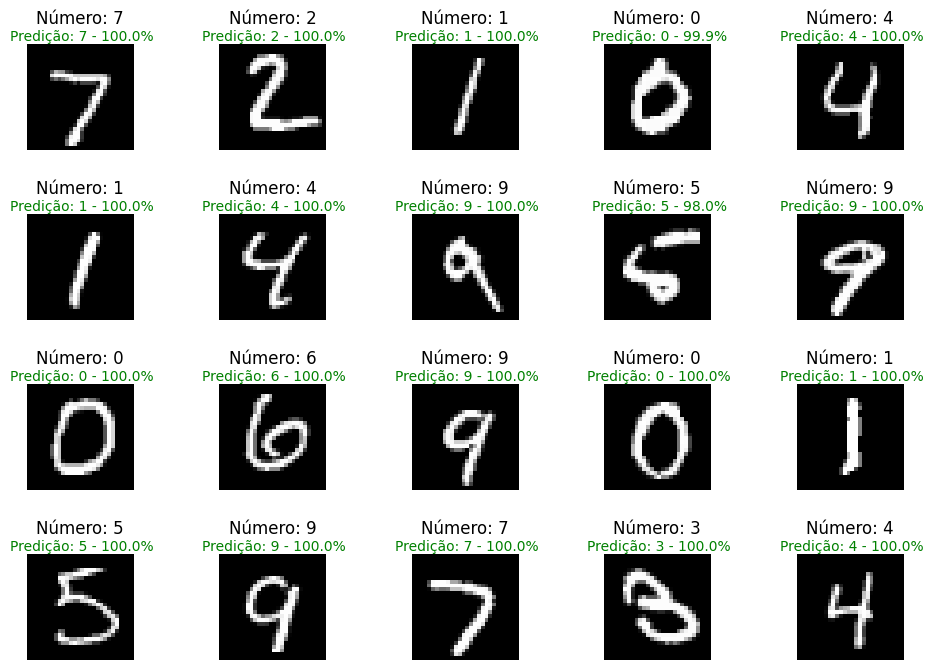

In [33]:
fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_test[i], cmap="gray")
    ax.set_title(f"Número: {y_test[i]}", pad=15)
    ax.axis("off")
    pred = model.predict(np.expand_dims(x_test[i], axis=0), verbose=0)[0]
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if pred.argmax() == y_test[i] else "red",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

https://www.tensorflow.org/api_docs/python/tf/keras/utils/load_img

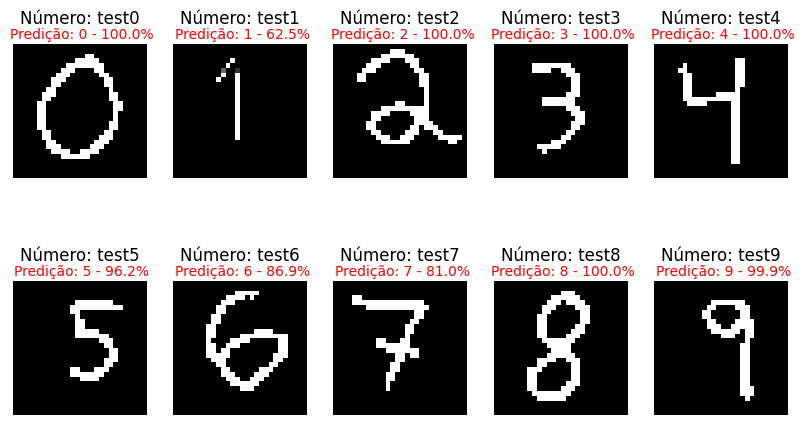

In [42]:
from pathlib import Path

test_images_dir = Path("imagensTeste")

fig, axs = plt.subplots(2, 5, figsize=(10, 5))

all_pred = {}

for i, (img, ax) in enumerate(zip(sorted(test_images_dir.glob("*.png")), axs.flat)):
    
    name = img.name.split(".")[0]
    
    img = keras.preprocessing.image.load_img(
        img, target_size=(28, 28), color_mode="grayscale"
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = 255 - img_array
    img_array = tf.expand_dims(img_array, 0)
    
    pred = model.predict(img_array, verbose=0)
    all_pred[name] = pred

    ax.imshow(img_array[0], cmap="gray")
    ax.set_title(f"Número: {name}", pad=15)
    ax.axis("off")
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if str(pred.argmax()) == name else "red",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

In [43]:
all_pred["test1"]

array([[1.1996619e-04, 6.2453479e-01, 1.4875020e-02, 1.4587514e-02,
        2.9635550e-03, 1.2606417e-03, 3.1423646e-05, 3.4050417e-01,
        6.0028135e-04, 5.2263925e-04]], dtype=float32)

In [44]:
all_pred["test5"]

array([[2.3292838e-11, 1.1669460e-13, 5.3539058e-08, 3.6850452e-02,
        3.8486014e-16, 9.6166557e-01, 1.9208678e-12, 7.9636450e-08,
        4.4066077e-08, 1.4838026e-03]], dtype=float32)